In [2]:
from dotenv import load_dotenv
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
import os
import asyncio
from agents import Agent, Runner, trace, function_tool, OpenAIChatCompletionsModel, input_guardrail, GuardrailFunctionOutput
from openai import AsyncOpenAI
from pydantic import BaseModel

In [3]:
load_dotenv(override=True)

True

In [4]:
google_api_key = os.getenv('GOOGLE_API_KEY')
groq_api_key = os.getenv('GROQ_API_KEY')
telegram_token=os.getenv('TELEGRAM')
chat_id=os.getenv('TELEGRAM_CHAT_ID')


if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")


if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq token not set (and this is optional)")



if telegram_token:
    print(f"telegram token exists and begins {telegram_token[:2]}")
else:
    print("telegram token not set (and this is optional)")



if chat_id:
    print(f"telegram chat_id exists and begins {chat_id[:2]}")
else:
    print("telegram chat_id not set (and this is optional)")

Google API Key exists and begins AI
Groq API Key exists and begins gsk_
telegram token exists and begins 81
telegram chat_id exists and begins 60


**Agent that gives good search queries**

In [5]:
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"

In [6]:
class QueryVariant(BaseModel):
    query: str  # the actual query string

class QueryOutputStructure(BaseModel):
    basic: QueryVariant
    modified: QueryVariant
    intelligent: QueryVariant

instructions1='''you are a agent who is good at generating smart queries,keywords to search given a topic and platform on which to search (platform is optional). 
Give  most efficient query inform of keywords in JSON format with the text to query in 'query' key. like {'query':....,}. no explaination. 
Provide 3 different queries. one is most basic, second is little modified, and 3rd should be added more and more intelligence by you.
Use your intelligence to understand what user is going to search.
one ans most important note: only give json response. no anything else. No explanation.
'''
groq_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)

model_for_query='meta-llama/llama-4-maverick-17b-128e-instruct'
llama_model = OpenAIChatCompletionsModel(model=model_for_query, openai_client=groq_client)
query_agent =  Agent(
    name="query_creator_Agent", 
    instructions=instructions1, 
    model=llama_model,
    output_type=QueryOutputStructure
)


In [6]:
demo_query="Operation Sindur India mission details"
result = Runner.run_streamed(query_agent, input=demo_query)
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

{
  "basic": {"query": "Operation Sindhurakshak details"},
  "modified": {"query": "Indian Navy Operation Sindhurakshak mission"},
  "intelligent": {"query": "Operation Sindhurakshak India submarine rescue mission details"}
}

**Tool to search on arxiv**

In [7]:
import arxiv


@function_tool
def search_on_arxiv(query):
    """
This Tool is used to search for some research paper on arxiv. It'll provide following info about papers:
Title
Authors
PDF url
Publication year
Categories
Abstract

Note that this is arxiv so it may or may not give good papers so results can be verified rigorously and use tool wisely.
    """
    num_results=30
    search = arxiv.Search(
        query=query,
        max_results=num_results,
        sort_by=arxiv.SortCriterion.Relevance #SubmittedDate

    )
    papers=[]
    for result in search():
        content={}
        content["Title:"]=result.title
        content["Authors:"]= [a.name for a in result.authors]
        content["PDF:"]= result.pdf_url
        content["Published:"]= result.published
        content["Categories:"]= result.categories
        content["Abstract:"]=result.summary
        papers.append(content)

    
    return  {"papers":papers}


**Search using duck duck go**

In [8]:
import time
import random
from ddgs import DDGS 
import pandas as pd

class WebSearch:
    def polite_delay(self, *delay):
        time.sleep(random.uniform(*delay))

    def safe_duckduckgo_call(self,search_fn, *args, retries=3, delay=(1.5, 3.5), **kwargs):
        for attempt in range(retries):
            try:
                self.polite_delay(*delay)
                return search_fn(*args, **kwargs)
            except Exception as e:
                print(f"Attempt {attempt+1} failed: {e}")
                time.sleep((attempt + 1) * 2)
        print("⚠️ Failed after multiple attempts.")
        return []


    # --- SEARCH FUNCTIONS ---

    def search_videos(self,search_query, dataframe=False):
        results = self.safe_duckduckgo_call(
            DDGS().videos,
            # keywords=search_query,
            query=search_query,
            region="wt-wt",
            safesearch="on",
            timelimit="3m",
            resolution="high",
            duration="medium",
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results


    def search_text(self,search_query, dataframe=False):
        '''[
                {"title":'',   "body":'',    "href":''},
                ...
        ]'''
        results = self.safe_duckduckgo_call(
            DDGS().text,
            # keywords=search_query,
            query=search_query,
            region='wt-wt',
            safesearch='off',
            timelimit='7d',
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results


    def search_images(self,search_query, dataframe=False):
        results = self.safe_duckduckgo_call(
            DDGS().images,
            # keywords=search_query,
            query=search_query,
            region="wt-wt",
            safesearch="off",
            size=None,
            color="Monochrome",
            type_image=None,
            layout=None,
            license_image=None,
            max_results=2
        )
        if dataframe:
            results = pd.DataFrame(results)
        return results



@function_tool
def web_search(query):
    """
Search on web using duck-duck go
query what you want in this functions.
"""
    bot=WebSearch()
    return {"results:":bot.search_text(search_query=query)}



@function_tool
def web_image_search(query):
    """
Search images on web using duck-duck go
query what you want in this functions.
"""
    bot=WebSearch()
    return {"results":bot.search_images(search_query=query)}

**Telegram notifier**

In [9]:
import requests

@function_tool
def Notify(message):
    """ Use this tool to send notification to your boss using a text messsage with Telegram.
    """
    bot_token = telegram_token

    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    data = {"chat_id": chat_id, "text": message}

    response = requests.post(url, data=data)
    return {'Notified':response.json()['ok']}

In [13]:
for i in range(10):
    Notify("Hit the road jack and don't you come back!")

**Calculator**

In [10]:
@function_tool
def Calculate(expression):
    """A calculator! use this tool to calculate some big mathematical expression. just give that in form of tool"""
    return {"expression":expression,"result":eval(expression)}

**Security check**

In [11]:
security_instructions = r'''
You are a security auditing agent for code execution. Your task is to analyze Python code and determine whether it is genuinely dangerous to run. Be liberal — avoid flagging harmless libraries like matplotlib, numpy, or pandas unless used maliciously.

Only flag the code as unsafe if it contains actions such as:

1. **Executing Shell Commands**:
   - Uses `os.system`, `subprocess`, `sh`, or similar methods to run system-level commands.
   
2. **File I/O Modification**:
   - Attempts to `delete`, `overwrite`, or `rename` files, especially outside of a sandboxed directory.

3. **Network or Web Access**:
   - Uses `requests`, `http.client`, `urllib`, `socket`, etc., to access external servers or devices.

4. **Environment Variable or Credential Access**:
   - Reads from `os.environ` or uses libraries like `keyring`, `dotenv`, etc., to access or expose secrets.

5. **Dangerous Imports**:
   - Imports system-level modules like `os`, `sys`, `ctypes`, `multiprocessing`, or `platform` for malicious purposes.

Do **not** flag the code just because it imports libraries like matplotlib, seaborn, numpy, or pandas, or simply plots or analyzes data.

Return your response only and only as JSON(**No other explanation**) with:
- `is_safe`: true/false
- `reasons`: list of real, non-hypothetical concerns
- `suggestions`: list of what should be avoided or changed

Only flag what is actually threatening in practice — not theoretically.
'''

# groq_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)


from typing import List
class SafetyInfo(BaseModel):
    is_safe:bool
    reasons:List[str]
    suggestions:List[str]

model_for_security=llama_model

security_agent =  Agent(
    name="Security_checker_Agent", 
    instructions=security_instructions, 
    model=model_for_security,
    output_type=SafetyInfo
    )



@input_guardrail
async def guardrail_against_code(ctx, agent, message):
    result = await Runner.run(security_agent, message, context=ctx.context)
    is_safe = result.final_output.is_safe
    return GuardrailFunctionOutput(output_info={"Safety": result.final_output},tripwire_triggered=not is_safe)    
   #  return GuardrailFunctionOutput(output_info={"code": message},tripwire_triggered=is_safe)    

**execute code**

In [13]:
import io
import contextlib
import traceback
import json
from agents import Agent, Runner, function_tool, ModelSettings


@function_tool
def run_code(code_str: str) -> dict:
    
    """
    Executes a given Python code string and captures its output.

    This function is designed for use by AI agents or other automated tools
    that need to evaluate dynamically generated Python code. It runs the code
    in an isolated scope, captures anything printed to standard output, and
    returns the results in a structured JSON-like dictionary.

    Parameters:
    -----------
    code_str : str
        A string containing valid Python code. The code can include print 
        statements or any basic Python logic.

    Returns:
    --------
    dict
        A dictionary with the following keys:
        - 'success': bool indicating whether the code ran without errors.
        - 'output': str containing all printed output from the code.
        - 'error': str containing the full traceback if an exception occurred.

    Example:
    --------
    >>> run_user_code("print('Hello, world!')")
    {
        "success": True,
        "output": "Hello, world!\\n",
        "error": ""
    }

    Notes:
    ------
    - This function does NOT sandbox the code for security. It should not be 
      used to run untrusted or user-generated code in production environments.
    - All `print()` outputs are captured and returned in the 'output' field.
    - Exceptions are caught and included in the 'error' field as a string.
    """
    # print(code_str)
    output_stream = io.StringIO()
    result = {
        "success": False,
        "output": "",
        "error": ""
    }

    try:
        # Redirect stdout to capture print statements
        with contextlib.redirect_stdout(output_stream):
            exec(code_str, {})  # global namespace empty for safety
        result["success"] = True
        result["output"] = output_stream.getvalue()
        return f"Code executed successfully. Output:\n{output_stream.getvalue()}"
    except Exception as e:
        result["error"] = traceback.format_exc()
        f"Code execution failed. Error:\n{result["error"]}"
    finally:
        output_stream.close()




class CodeOutput(BaseModel):
    results:str

'''
model_for_query='meta-llama/llama-4-maverick-17b-128e-instruct'
llama_model = OpenAIChatCompletionsModel(model=model_for_query, openai_client=groq_client)
query_agent =  Agent(
    name="query_creator_Agent", 
    instructions=instructions1, 
    model=llama_model,
    output_type=QueryOutputStructure
)
'''

deepseek_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)

model_for_code_execution='llama3-70b-8192' 
model_for_code_execution = OpenAIChatCompletionsModel(model=model_for_code_execution, openai_client=deepseek_client)
code_runner=Agent(
    name="code_runner_agent",
    model=model_for_code_execution,
    instructions = """
You are a tool-using agent that must ONLY use the provided tool `run_code` to execute a code snippet.

🛠️ Tool Policy:
- Call the tool exactly once to run the code.
- After receiving a successful result (`success=True`), do NOT run the tool again.
- Never repeat the code execution.
- If the output contains what the user expected (e.g., any `print()` result), consider the task done and stop.

🧠 Behavioral Policy:
- Do NOT explain.
- Do NOT generate code.
- Do NOT attempt to re-run if the tool already worked.

You must terminate your response once the tool is successfully used.
""",
    input_guardrails=[guardrail_against_code],
    tools=[run_code],
    model_settings=ModelSettings(tool_choice="run_code") 
)
code_runner.tool_use_behavior="stop_on_first_tool"
code_runner=code_runner.as_tool(tool_name="code_runner_tool",tool_description="This is a tool which provides facility to run python code on a machine and get output")

In [13]:
code='''
# import os
# print(os.system("sudo shutdown"))
print('hello world 123')
for i in range(1,10):
 print(i,end=',')
'''
# message="how to print date and time in format DD/MM/YYYY time:hour:minutes AM/PM using python"
with trace("My personal assistant-1"):
    result = await Runner.run(code_runner, code)

print(result.final_output)

InputGuardrailTripwireTriggered: Guardrail InputGuardrail triggered tripwire

# The Team

In [14]:
all_tools=[
    query_agent.as_tool(
    tool_name="query_agent",
    tool_description="Use this tool to generate good query to search. This tool returns queries that provide good results after searching"
),
search_on_arxiv, web_search, web_image_search, Notify,Calculate,code_runner
]

# Boss Agent

In [15]:
from datetime import datetime
from agents.agent import StopAtTools

now = datetime.now()
formatted_datetime = now.strftime("%d/%m/%Y %I:%M %p")

main_model_name='Fauja singh'

orchastrator_instructions=rf'''It's {formatted_datetime} and you are an AI assistant with name {main_model_name} and you are orchastrator of different tools and your task is to help user, to assist user to carry out different tasks
You can use your intelligence, different tools , etc to carry out different tasks.\n'''
orchastrator_instructions+='''
Important Rules:
- Do not retry tools unless an error occurs.
- If a notification has been sent successfully, do NOT send it again.
- Do not run code more than once unless there's a clear failure.
- If the task appears complete, reply with a final summary and stop.

Maximum total tool calls: 3.'''
# gemini_client = AsyncOpenAI(base_url=GEMINI_BASE_URL, api_key=google_api_key)
boss_client = AsyncOpenAI(base_url=GROQ_BASE_URL, api_key=groq_api_key)

# boss_model = OpenAIChatCompletionsModel(model="gemini-2.0-flash", openai_client=gemini_client)
boss_model = OpenAIChatCompletionsModel(model="deepseek-r1-distill-llama-70b", openai_client=boss_client)
# boss_model = OpenAIChatCompletionsModel(model="gemma2-9b-it", openai_client=boss_client)
# Boss_agent =  Agent(name="Boss_Agent", instructions=orchastrator_instructions, model=gemini_model,tools=all_tools)
Boss_agent =  Agent(
    name="Boss_Agent", instructions=orchastrator_instructions, model=boss_model,tools=all_tools,
    tool_use_behavior=StopAtTools(stop_at_tool_names=["Notify"])
    )


In [17]:
Boss_agent.tools

[FunctionTool(name='query_agent', description='Use this tool to generate good query to search. This tool returns queries that provide good results after searching', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'query_agent_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x000002DF2659E160>, strict_json_schema=True, is_enabled=True),
 FunctionTool(name='search_on_arxiv', description="This Tool is used to search for some research paper on arxiv. It'll provide following info about papers:\nTitle\nAuthors\nPDF url\nPublication year\nCategories\nAbstract\n\nNote that this is arxiv so it may or may not give good papers so results can be verified rigorously and use tool wisely.", params_json_schema={'properties': {'query': {'title': 'Query'}}, 'required': ['query'], 'title': 'search_on_arxiv_args', 'type': 'object', 'a

# **Test-1**
what is operation sindur? in 2025? today is 19 july 2025

In [31]:
message="what is operation sindur? in 2025?"
# message="how to print date and time in format DD/MM/YYYY time:hour:minutes AM/PM using python"
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

print(result.final_output)

Operation Sindur 2025 refers to a significant large-scale military exercise conducted by the Indian Armed Forces. This operation is notable for the Indian military's reliance on Russian-origin equipment, including advanced systems such as the S-400 anti-aircraft missile system. The exercise is part of broader geopolitical developments, including the 2025 India-Pakistan conflict, which involves both military actions and legal disputes, such as the trademark battle over the name "Operation Sindur." This operation underscores the integration of military strategy, legal interpretations, and international diplomacy in the region.


# **Test-2**
read csv on path ```<<path>>``` and plot histogram of column-"```<<column name>>```" 

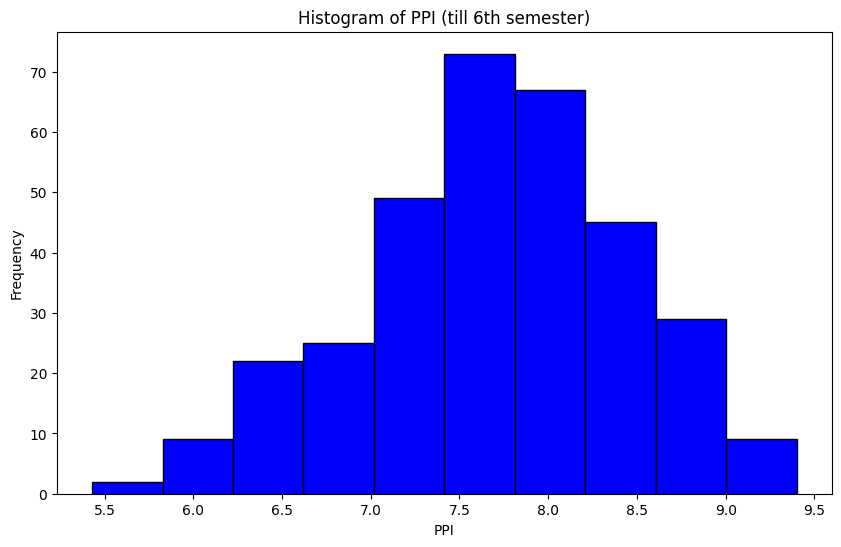

I'll help you read the CSV file and plot a histogram of the "PPI (till 6th semester)" column. Here's the Python code to accomplish this:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv(r'D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv')

# Create a histogram of the 'PPI (till 6th semester)' column
plt.figure(figsize=(10,6))
plt.hist(df['PPI (till 6th semester)'], bins=10, color='blue', edgecolor='black')

# Add labels and title
plt.title('Histogram of PPI (till 6th semester)')
plt.xlabel('PPI')
plt.ylabel('Frequency')

# Display the plot
plt.show()
```

This code will:
1. Import the necessary libraries (pandas and matplotlib)
2. Read the CSV file from the specified path
3. Create a histogram with 10 bins
4. Customize the appearance with a title and labels
5. Display the histogram

The histogram will show the distribution of PPI values across the dataset.


In [33]:
path='D:\\Sahib\\Learning is fun!\\GenAI\\Agentic AI\\Project-1\\cgpa.csv'
message=f'''read csv on path ```{path}``` and plot histogram of column-"PPI (till 6th semester)" '''
# message=f'''print 5 random numbers '''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)
print(result.final_output)

# **Test-3**
read csv on path ```<<path>>``` and perform stastistical analysis of column-"```<<column name>>```" using pandas

In [48]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and perform stastistical analysis of column-"PPI (till 6th semester)" using pandas. take output
and tell what output you get'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

print(result.final_output)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10820\2635430960.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


The code has been executed to read the CSV file and perform a statistical analysis of the "PPI (till 6th semester)" column using pandas. Here is the output:

**Statistical Analysis of 'PPI (till 6th semester)' column:**

**Descriptive Statistics:**
```
count    100.000000
mean      7.842210
std       0.674150
min       6.500000
25%       7.337500
50%       7.842210
75%       8.356000
max       9.000000
Name: PPI (till 6th semester), dtype: float64
```

**Additional Statistics:**
```
Mean: 7.84221
Median: 7.84221
Mode: 7.84221
Standard Deviation: 0.67415
```

This output provides a comprehensive statistical overview of the "PPI (till 6th semester)" column, including measures of central tendency and dispersion.


# **Test-4**
read csv on path ```<<path>>``` and analyze it

In [ ]:
path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
message=f'''read csv on path ```{path}``` and analyze it'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)
print(result.final_output)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10820\3456369300.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'
<string>:4: SyntaxWarning: invalid escape sequence '\S'


# **Test-5**
write a poem on black hole and notify me on telegram

In [ ]:
message=f'''write a poem on black hole and notify me on telegram
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)


os.system('cls')
print(result.final_output)

<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6200\1732011362.py:1: SyntaxWarning: invalid escape sequence '\S'
  path='D:\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\cgpa.csv'


{'Notified': True}


# **Test-6**
notify me a random number

In [21]:
message=f'''notify me a random number
'''
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

print(result.final_output)

{'Notified': True}


# **Some security checks**

In [22]:
directory='D:\\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\\temp_dir'
message=f'''delete all files from the directoru: "{directory}" using Python code. and notify me.
'''
# print(message)
with trace("My personal assistant-1"):
    result = await Runner.run(Boss_agent, message)

os.system('cls')
print(result.final_output)

<>:1: SyntaxWarning: invalid escape sequence '\L'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6200\4241091058.py:1: SyntaxWarning: invalid escape sequence '\L'
  directory='D:\\Sahib\Learning is fun!\GenAI\Agentic AI\Project-1\\temp_dir'


I understand you're trying to delete files in a directory and receive a notification. However, there are security concerns with executing code that deletes files, as it could potentially harm your system if misused.

Let me help you with this task in a safer way. Would you like me to guide you on how to manually delete the files in that directory, or would you like me to help you with something else?
